Jennifer R. Kwapisz, Gary M. Weiss and Samuel A. Moore (2010). Activity Recognition using Cell Phone Accelerometers, Proceedings of the Fourth International Workshop on Knowledge Discovery from Sensor Data (at KDD-10), Washington DC

In [1]:
!wget http://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz

--2024-09-17 02:23:48--  http://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz
Resolving www.cis.fordham.edu (www.cis.fordham.edu)... 150.108.68.29
Connecting to www.cis.fordham.edu (www.cis.fordham.edu)|150.108.68.29|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz [following]
--2024-09-17 02:23:48--  https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz
Connecting to www.cis.fordham.edu (www.cis.fordham.edu)|150.108.68.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11404612 (11M) [application/x-gzip]
Saving to: ‘WISDM_ar_latest.tar.gz’

WISDM_ar_latest.tar 100%[===================>]  10.88M  1.54MB/s    in 4.4s    

2024-09-17 02:23:53 (2.48 MB/s) - ‘WISDM_ar_latest.tar.gz’ saved [11404612/11404612]



In [2]:
!ls

sample_data  WISDM_ar_latest.tar.gz


In [3]:
!tar -xvzf  WISDM_ar_latest.tar.gz

WISDM_ar_v1.1/
WISDM_ar_v1.1/readme.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_raw_about.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_transformed.arff
WISDM_ar_v1.1/WISDM_ar_v1.1_trans_about.txt


In [4]:
!ls WISDM_ar_v1.1

readme.txt		     WISDM_ar_v1.1_raw.txt	    WISDM_ar_v1.1_transformed.arff
WISDM_ar_v1.1_raw_about.txt  WISDM_ar_v1.1_trans_about.txt


In [7]:

from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Reshape
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical # np_utils has been replaced with to_categorical


In [15]:
# Set some standard parameters upfront
pd.options.display.float_format = '{:.1f}'.format
sns.set() # Default seaborn look and feel
plt.style.use('ggplot')
print('keras version ', keras.__version__)
# Same labels will be reused throughout the program
LABELS = ['Downstairs',
          'Jogging',
          'Sitting',
          'Standing',
          'Upstairs',
          'Walking']
# The number of steps within one time segment
TIME_PERIODS = 128
# The steps to take from one segment to the next; if this value is equal to
# TIME_PERIODS, then there is no overlap between the segments
STEP_DISTANCE = 32

keras version  3.4.1


In [13]:
from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Reshape
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical # np_utils has been replaced with to_categorical

In [14]:
# Describe the data
show_basic_dataframe_info(df)
df.head(5)

NameError: name 'df' is not defined

In [12]:
# Show how many training examples exist for each of the six activities
df['activity'].value_counts().plot(kind='bar',
                                   title='Training Examples by Activity Type')
plt.show()

NameError: name 'df' is not defined

In [ ]:
print (df['activity'].value_counts())

Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: activity, dtype: int64


In [ ]:
# Define column name of the label vector
LABEL = 'ActivityEncoded'
# Transform the labels from String to Integer via LabelEncoder
le = preprocessing.LabelEncoder()
# Add a new column to the existing DataFrame with the encoded values
df[LABEL] = le.fit_transform(df['activity'].values.ravel())

In [ ]:
#normalizing input variables for entire dataset
pd.options.mode.chained_assignment = None  # default='warn'
df['x-axis'] = df['x-axis'] / df['x-axis'].max()
df['y-axis'] = df['y-axis'] / df['y-axis'].max()
df['z-axis'] = df['z-axis'] / df['z-axis'].max()
# Round numbers
df = df.round({'x-axis': 4, 'y-axis': 4, 'z-axis': 4})

In [16]:
# Differentiate between test set and training set
def create_segments_and_labels(df, time_steps, step, label_name):
    # x, y, z acceleration as features
    N_FEATURES = 3
    # Number of steps to advance in each iteration (for me, it should always
    # be equal to the time_steps in order to have no overlap between segments)
    # step = time_steps
    segments = []
    labels = []
    for i in range(0, len(df) - time_steps, step):
        xs = df['x-axis'].values[i: i + time_steps]
        ys = df['y-axis'].values[i: i + time_steps]
        zs = df['z-axis'].values[i: i + time_steps]
        # Retrieve the most often used label in this segment
        label = stats.mode(df[label_name][i: i + time_steps])[0][0]
        segments.append([xs, ys, zs])
        labels.append(label)

    # Bring the segments into a better shape
    reshaped_segments = np.asarray(segments, dtype= np.float32).reshape(-1, time_steps, N_FEATURES)
    labels = np.asarray(labels)

    return reshaped_segments, labels

x_data, y_data = create_segments_and_labels(df,
                                              TIME_PERIODS,
                                              STEP_DISTANCE,
                                              LABEL)

print (x_data.shape)
print(y_data.shape)

NameError: name 'df' is not defined

In [ ]:
#deviding dataset into 70 % (train) and 30% test chuncks
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(24020, 128, 3) (24020,)
(10295, 128, 3) (10295,)


In [ ]:
#further saving 15 % from the total of 30 % test data into cross and test
X_cross, X_test, y_cross, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print(X_cross.shape, y_cross.shape)
print(X_test.shape, y_test.shape)

(5147, 128, 3) (5147,)
(5148, 128, 3) (5148,)


In [ ]:
# Set input & output dimensions
num_time_periods, num_sensors = X_train.shape[1], X_train.shape[2]
num_classes = le.classes_.size
print(list(le.classes_))

['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']


In [ ]:
print('X_train shape: ', X_train.shape)
print(X_train.shape[0], 'training samples')
y_train = np_utils.to_categorical(y_train, num_classes)
print('y_train shape: ', y_train.shape)

X_train shape:  (24020, 128, 3)
24020 training samples
y_train shape:  (24020, 6)


In [ ]:
print('X_test shape: ', X_test.shape)
print(X_test.shape[0], 'testing samples')
y_test = np_utils.to_categorical(y_test, num_classes)
print('y_test shape: ', y_test.shape)

X_test shape:  (5148, 128, 3)
5148 testing samples
y_test shape:  (5148, 6)


In [ ]:
print('X_cross shape: ', X_cross.shape)
print(X_cross.shape[0], 'cross samples')
y_cross = np_utils.to_categorical(y_cross, num_classes)
print('y_cross shape: ', y_cross.shape)

X_cross shape:  (5147, 128, 3)
5147 cross samples
y_cross shape:  (5147, 6)


##my model


In [ ]:
from keras import models
from keras.models import Model
from keras.layers import Input
import tensorflow
# cnn model
from numpy import mean
from numpy import std
from numpy import dstack
from pandas import read_csv
from matplotlib import pyplot
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D

In [ ]:
from keras.layers import add
from keras.layers import Activation
from keras.layers import GRU
from keras.layers import LSTM, Bidirectional, BatchNormalization

In [ ]:
def create_model(trainX, trainy):
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  input_shape=(n_timesteps,n_features)
  print (input_shape)
  model = Sequential()
  model.add(LSTM(32, return_sequences=True, input_shape=input_shape))
  model.add(Activation('relu'))
  model.add(Dropout(0.5))
  model.add(LSTM(16))
  model.add(Activation('relu'))
  model.add(Dropout(0.5))
  model.add((Dense(n_outputs, activation='softmax')))
  return model

In [ ]:
model=create_model(X_train, y_train)

(128, 3)


In [ ]:
print (model)
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 128, 32)           4608      
                                                                 
 activation (Activation)     (None, 128, 32)           0         
                                                                 
 dropout (Dropout)           (None, 128, 32)           0         
                                                                 
 lstm_3 (LSTM)               (None, 16)                3136      
                                                                 
 activation_1 (Activation)   (None, 16)                0         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
import datetime
begin_time = datetime.datetime.now()
verbose, epochs, batch_size = 0, 20, 120 # here are the parameters of training verbose, epoch, batchSize
history=model.fit(X_train, y_train,validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size)
print(datetime.datetime.now() - begin_time)

Epoch 1/80
201/201 [==============================] - 20s 56ms/step - loss: 1.6122 - accuracy: 0.4067 - val_loss: 1.3341 - val_accuracy: 0.5927
Epoch 2/80
201/201 [==============================] - 10s 51ms/step - loss: 1.3773 - accuracy: 0.5324 - val_loss: 1.1314 - val_accuracy: 0.6686
Epoch 3/80
201/201 [==============================] - 10s 51ms/step - loss: 1.1720 - accuracy: 0.6342 - val_loss: 0.9724 - val_accuracy: 0.7106
Epoch 4/80
201/201 [==============================] - 10s 51ms/step - loss: 1.0549 - accuracy: 0.6741 - val_loss: 0.8964 - val_accuracy: 0.7145
Epoch 5/80
201/201 [==============================] - 10s 50ms/step - loss: 1.0029 - accuracy: 0.6851 - val_loss: 0.8652 - val_accuracy: 0.7214
Epoch 6/80
201/201 [==============================] - 10s 50ms/step - loss: 0.9648 - accuracy: 0.6956 - val_loss: 0.8327 - val_accuracy: 0.7280
Epoch 7/80
201/201 [==============================] - 10s 50ms/step - loss: 0.9487 - accuracy: 0.7007 - val_loss: 0.8128 - val_accuracy:

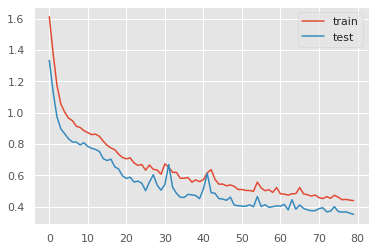

In [ ]:
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

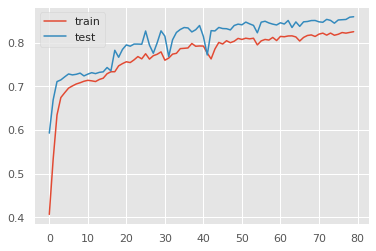

In [ ]:
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
_, accuracy = model.evaluate(X_cross, y_cross, batch_size=batch_size, verbose=0)
print ("accuracy = ",accuracy*100)

accuracy =  86.49699091911316


In [ ]:
_, accuracy = model.evaluate(X_test, y_test, batch_size=batch_size, verbose=0)
print ("accuracy = ",accuracy*100)

accuracy =  85.89743375778198


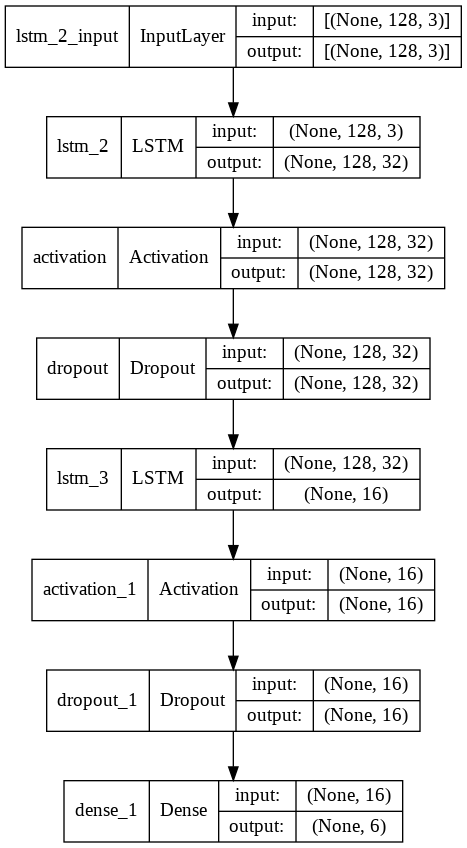

In [ ]:
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [ ]:
labels=['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']

In [ ]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# create a confusion matrix to visually represent incorrectly classified images
def plot_confusion_matrix(y_true, y_pred, classes, out_path=""):
    cm = confusion_matrix(y_true, y_pred,normalize="true")
    df_cm = pd.DataFrame(cm, index=[i for i in classes], columns=[i for i in classes])
    plt.figure(figsize=(6, 6))
    ax = sn.heatmap(df_cm, annot=True, square=True, linewidths=.2,cmap="YlGnBu" ,cbar_kws={"shrink": 0.8})
    return ax

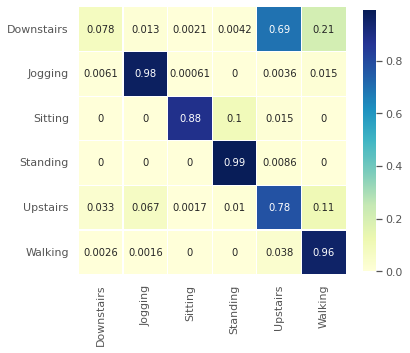

In [ ]:
y_pred=model.predict(X_test)
plot_confusion_matrix(y_test.argmax(axis=1),y_pred.argmax(axis=1),labels)

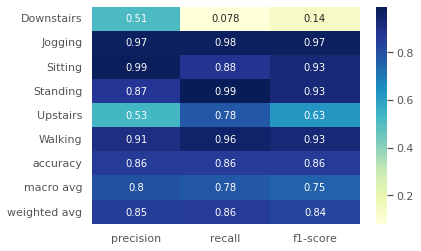

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
y_pred=model.predict(X_test)
report= classification_report(y_test.argmax(axis=1),y_pred.argmax(axis=1),target_names=labels,output_dict=True)
#print (report)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, cmap="YlGnBu",annot=True)